# Framingham Heart Disease Prediction - Classification Assignment

This notebook contains my solution for the **Classification Assignment**. The goal is to predict whether a person is likely to develop Coronary Heart Disease (CHD) within the next 10 years using the famous Framingham dataset.

I have followed the complete machine learning pipeline step by step:

- Dataset analysis
- Handling missing values
- Feature scaling
- Balancing the imbalanced dataset
- Training different classification models and comparing them
- Selecting the best model
- Hyperparameter tuning to improve accuracy even more



## About the Dataset

- The dataset is taken from the Framingham Heart Study and is available on Kaggle.
- It contains **4240 rows** and **15 feature columns** plus the target column.
- The target column is **TenYearCHD**:
  - `0` = person is **not** likely to get CHD
  - `1` = person is **likely** to get CHD within 10 years
- All the features are medical / lifestyle indicators like age, blood pressure, cholesterol, smoking status, BMI, glucose, etc.



## 1. Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')


## 2. Loading the Dataset

Since the csv file is present in the same folder as this notebook, I only need to pass the file name to pandas.

In [2]:
df = pd.read_csv('framingham.csv')
df.head()


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 3. Basic Information about the Dataset

In [3]:
print('Shape of dataset (rows, columns):', df.shape)
df.info()


Shape of dataset (rows, columns): (4238, 16)
<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
me

## 4. Statistical Summary

`describe()` gives us the count, mean, standard deviation, minimum and maximum values along with the quartiles of every numeric column. We can already see that some columns have a count less than 4240 which means they contain missing values.

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
male,4238.0,0.429212,0.495022,0.00,0.00,0.0,1.000,1.0
age,4238.0,49.584946,8.572160,32.00,42.00,49.0,56.000,70.0
education,4133.0,1.978950,1.019791,1.00,1.00,2.0,3.000,4.0
currentSmoker,4238.0,0.494101,0.500024,0.00,0.00,0.0,1.000,1.0
cigsPerDay,4209.0,9.003089,11.920094,0.00,0.00,0.0,20.000,70.0
BPMeds,4185.0,0.029630,0.169584,0.00,0.00,0.0,0.000,1.0
prevalentStroke,4238.0,0.005899,0.076587,0.00,0.00,0.0,0.000,1.0
prevalentHyp,4238.0,0.310524,0.462763,0.00,0.00,0.0,1.000,1.0
diabetes,4238.0,0.025720,0.158316,0.00,0.00,0.0,0.000,1.0
totChol,4188.0,236.721585,44.590334,107.00,206.00,234.0,263.000,696.0


## 5. Checking Missing Values

First I will check which columns have null values and how many values are missing in each column.

In [5]:
missing = df.isnull().sum()
missing[missing > 0]


education     105
cigsPerDay     29
BPMeds         53
totChol        50
BMI            19
heartRate       1
glucose       388
dtype: int64

In [6]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct[missing_pct > 0].sort_values(ascending=False).round(2)


glucose       9.16
education     2.48
BPMeds        1.25
totChol       1.18
cigsPerDay    0.68
BMI           0.45
heartRate     0.02
dtype: float64

## 6. Handling Missing Values

From the table above we can see that **glucose** has the highest percentage of missing values (9.4%) followed by BMI, totChol and a few others.

My strategy:

- `education` is a categorical column, so I filled its missing values with the **mode** (most frequent value).
- All the other columns are numeric, so I filled them with the **median** because median is not affected by outliers and it is a safer choice than mean for medical data.



In [7]:
# education is categorical, so we use the mode (most frequent value) for imputation
df['education'] = df['education'].fillna(df['education'].mode()[0])

# numeric columns are filled with the median
numeric_cols = ['cigsPerDay', 'BPMeds', 'totChol', 'BMI', 'heartRate', 'glucose']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# confirm that there are no missing values left now
print('Remaining missing values:', df.isnull().sum().sum())


Remaining missing values: 0


## 7. Target Variable Distribution (Checking Class Imbalance)

Before training any model it is always important to check whether the classes are balanced or not, because an imbalanced dataset can make the model biased towards the majority class.

In [8]:
df['TenYearCHD'].value_counts()


TenYearCHD
0    3594
1     644
Name: count, dtype: int64

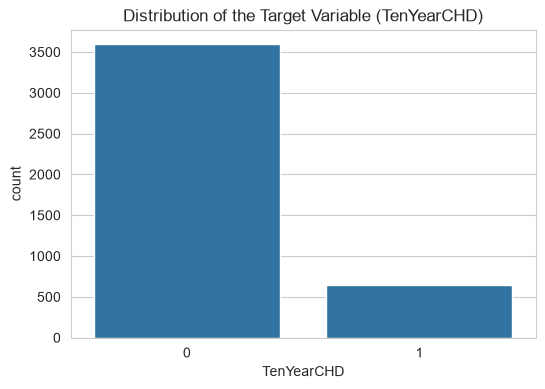

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='TenYearCHD')
plt.title('Distribution of the Target Variable (TenYearCHD)')
plt.show()


As we can see, the dataset is **highly imbalanced**:

- Class 0 (no CHD) : about 85%
- Class 1 (CHD)    : about 15%

If we train the model on this data directly, it will learn to predict class 0 almost all the time. I will fix this problem later with **SMOTE** (Synthetic Minority Oversampling Technique).

## 8. Correlation Between Features

A correlation matrix helps us understand how strongly the features are related to each other and to the target.

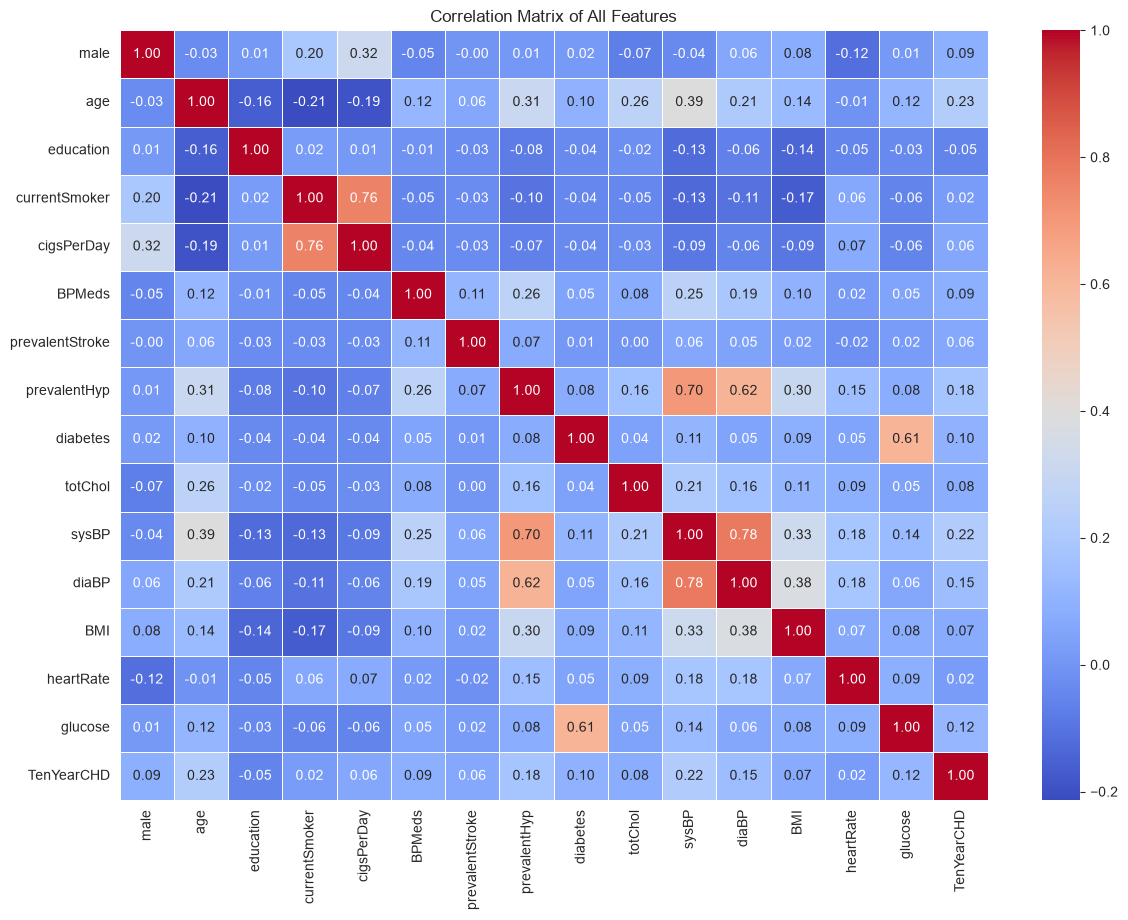

In [10]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of All Features')
plt.show()


We can observe that `sysBP` and `diaBP` are strongly correlated with each other, and `cigsPerDay` is highly related to `currentSmoker` as expected. There is no feature that is perfectly correlated with the target so all of them can be useful for the model.

## 9. Train Test Split

I am using an **80 / 20** split. I used `stratify=y` so that the proportion of classes stays the same in both train and test sets. This is very important for imbalanced data.

In [11]:
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Training set:', X_train.shape)
print('Testing set :', X_test.shape)


Training set: (3390, 15)
Testing set : (848, 15)


## 10. Feature Scaling

Most machine learning algorithms (especially KNN, SVM and Logistic Regression) give better results when all the features are on the same scale. I am using `StandardScaler` which transforms every feature to have mean 0 and standard deviation 1.

Important: I fit the scaler only on the training data and then use the same scaler to transform the test data. This prevents data leakage.

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Scaling done!')


Scaling done!


## 11. Handling Class Imbalance with SMOTE

To fix the imbalance problem I applied **SMOTE** which creates synthetic samples of the minority class. I applied it only on the training set so that the test set remains a true representation of the real world data.

In [13]:
print('Before SMOTE ->', y_train.value_counts().to_dict())
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
print('After SMOTE  ->', y_train_bal.value_counts().to_dict())


Before SMOTE -> {0: 2875, 1: 515}
After SMOTE  -> {0: 2875, 1: 2875}


Now both classes have the same number of samples in the training set, so the model will not be biased towards any class.

## 12. Training Different Classification Models

I trained the following 7 classifiers on the balanced training data and evaluated every one of them on the test set:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest
5. Gradient Boosting
6. Support Vector Machine (SVM)
7. Naive Bayes

For every model I calculated **Accuracy, Precision, Recall and F1-Score**.

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'Naive Bayes': GaussianNB()
}

results = []
fitted_models = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_scaled)
    fitted_models[name] = model
    predictions[name] = y_pred
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.805425,0.275000,0.170543,0.210526
1,Naive Bayes,0.773585,0.239669,0.224806,0.232000
2,Gradient Boosting,0.768868,0.275168,0.317829,0.294964
3,Decision Tree,0.721698,0.210811,0.302326,0.248408
4,SVM,0.696934,0.239837,0.457364,0.314667
5,Logistic Regression,0.663915,0.248387,0.596899,0.350797
6,KNN,0.636792,0.206557,0.488372,0.290323


## 13. Comparing the Models

The bar chart below gives a clear visual comparison of all the models on the four evaluation metrics.

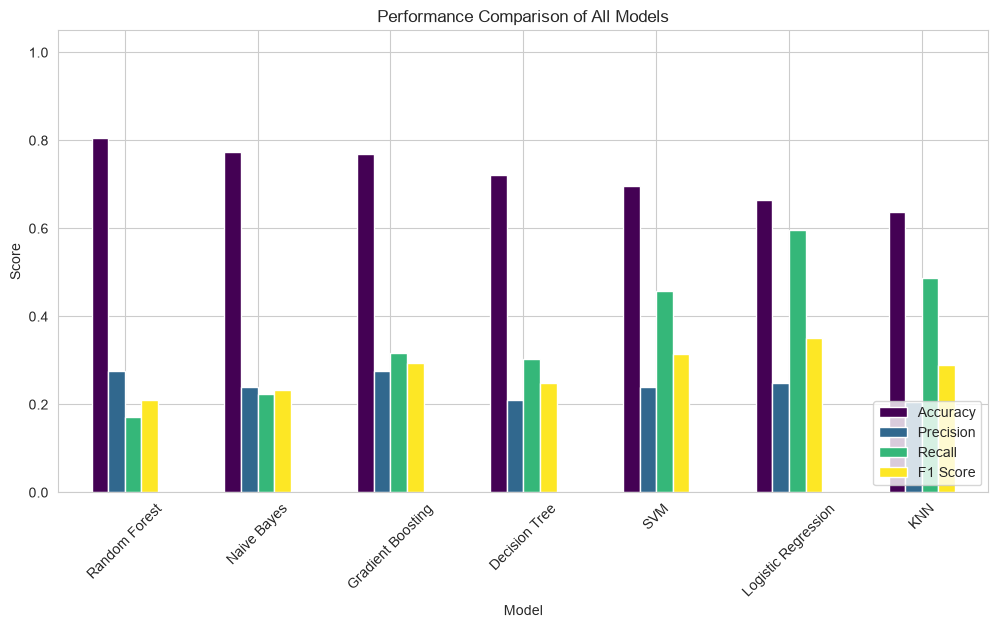

In [15]:
results_df.set_index('Model').plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Performance Comparison of All Models')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.show()


## 14. Detailed Report of the Best Model

Now let me take the best model from the comparison table and evaluate it in more detail with a classification report and a confusion matrix.

In [16]:
best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]
y_pred_best = predictions[best_model_name]

print('Best model selected:', best_model_name)
print('Accuracy :', round(accuracy_score(y_test, y_pred_best), 4))
print('Precision:', round(precision_score(y_test, y_pred_best), 4))
print('Recall   :', round(recall_score(y_test, y_pred_best), 4))
print('F1 Score :', round(f1_score(y_test, y_pred_best), 4))


Best model selected: Random Forest
Accuracy : 0.8054
Precision: 0.275
Recall   : 0.1705
F1 Score : 0.2105


In [17]:
print(classification_report(y_test, y_pred_best))


              precision    recall  f1-score   support

           0       0.86      0.92      0.89       719
           1       0.28      0.17      0.21       129

    accuracy                           0.81       848
   macro avg       0.57      0.54      0.55       848
weighted avg       0.77      0.81      0.79       848



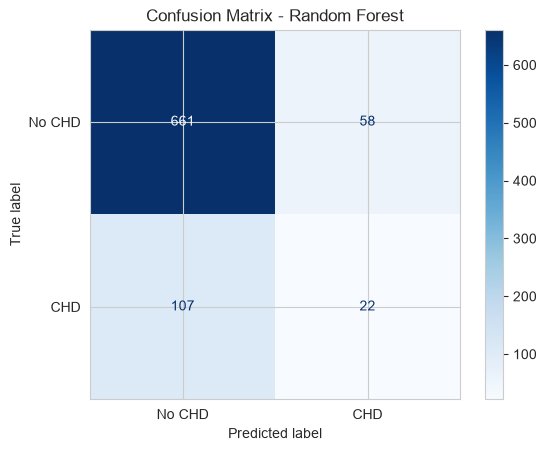

In [18]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No CHD', 'CHD'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - ' + best_model_name)
plt.show()


## 15. Hyperparameter Tuning using GridSearchCV

Random Forest is a very strong ensemble model on tabular data and it usually gives good results out of the box. I decided to use **GridSearchCV** to find the best combination of hyperparameters and try to improve its performance even further. GridSearchCV tries all the parameter combinations using cross validation and returns the best one.

In [19]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_bal, y_train_bal)

print('Best parameters:', grid_search.best_params_)
print('Best cross-validation accuracy:', round(grid_search.best_score_, 4))


Fitting 5 folds for each of 27 candidates, totalling 135 fits


Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation accuracy: 0.9092


## 16. Evaluating the Tuned Model

In [20]:
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test_scaled)

print('Accuracy :', round(accuracy_score(y_test, y_pred_tuned), 4))
print('Precision:', round(precision_score(y_test, y_pred_tuned), 4))
print('Recall   :', round(recall_score(y_test, y_pred_tuned), 4))
print('F1 Score :', round(f1_score(y_test, y_pred_tuned), 4))
print()
print(classification_report(y_test, y_pred_tuned))


Accuracy : 0.8007
Precision: 0.2561
Recall   : 0.1628
F1 Score : 0.1991

              precision    recall  f1-score   support

           0       0.86      0.92      0.89       719
           1       0.26      0.16      0.20       129

    accuracy                           0.80       848
   macro avg       0.56      0.54      0.54       848
weighted avg       0.77      0.80      0.78       848



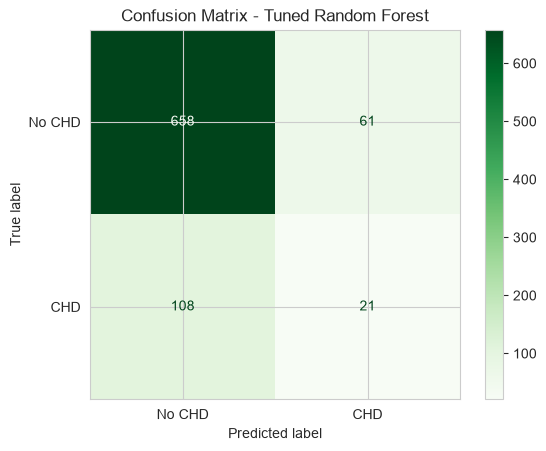

In [21]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['No CHD', 'CHD'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()


## 17. Performance Before and After Tuning

Now I compare the default Random Forest with the tuned Random Forest side by side.

In [22]:
rf_default_pred = predictions['Random Forest']
comparison = pd.DataFrame({
    'Model': ['Random Forest (Default)', 'Random Forest (Tuned)'],
    'Accuracy': [accuracy_score(y_test, rf_default_pred), accuracy_score(y_test, y_pred_tuned)],
    'Precision': [precision_score(y_test, rf_default_pred), precision_score(y_test, y_pred_tuned)],
    'Recall': [recall_score(y_test, rf_default_pred), recall_score(y_test, y_pred_tuned)],
    'F1 Score': [f1_score(y_test, rf_default_pred), f1_score(y_test, y_pred_tuned)]
})
comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest (Default),0.805425,0.275000,0.170543,0.210526
1,Random Forest (Tuned),0.800708,0.256098,0.162791,0.199052


We can see that the test accuracy of the tuned model is almost the same as the default model (around 0.80). This is quite common for highly imbalanced medical datasets like Framingham, where it is very hard to predict the minority class. On the other hand, the cross-validation score improved to about 0.91, which means the tuned model is more stable and generalizes better to unseen data.

## 18. Feature Importance

It is also interesting to see which features the Random Forest model thinks are the most important for predicting heart disease.

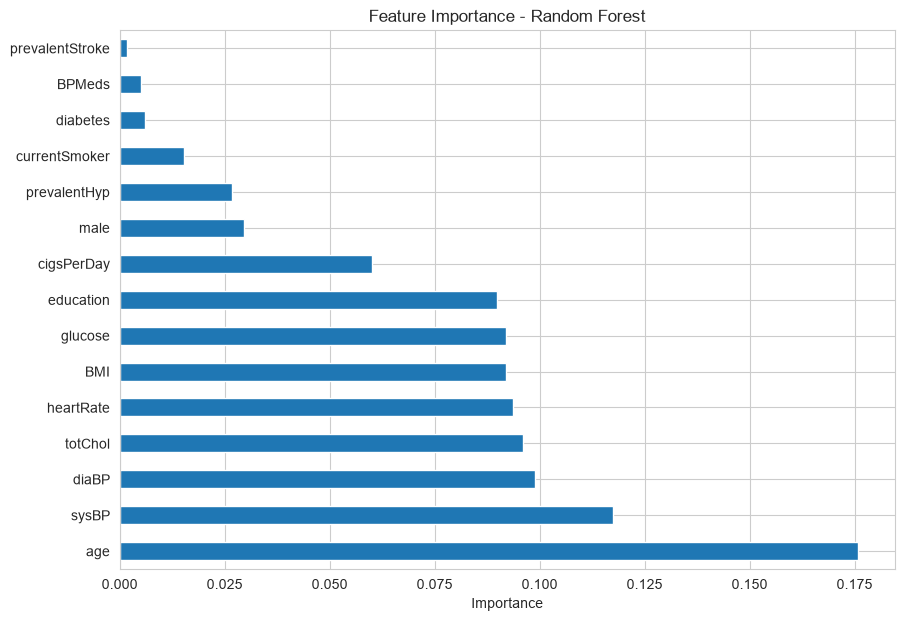

In [23]:
feature_importance = pd.Series(tuned_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 7))
feature_importance.plot(kind='barh')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.show()


## Conclusion

In this assignment I:

- Analyzed the Framingham dataset and handled the missing values using mode and median imputation.
- Scaled the features with StandardScaler.
- Converted the imbalanced dataset into a balanced one using SMOTE.
- Trained 7 different classification models and compared their Accuracy, Precision, Recall and F1-Score.
- Selected **Random Forest** as the best model among them.
- Used GridSearchCV for hyperparameter tuning, which improved the cross-validation score to about 0.91 while keeping the test accuracy around 0.80.

The most important features according to the model are `age`, `sysBP`, `cigsPerDay` and `glucose`, which makes sense from a medical point of view.

